## Task 3

In [42]:
''' 1. Read
the dataset and seperate the input and output columns 2. Perform
train-test split with 75% and 25%
3. Create decision tree model
4. Find Mean absolute error and accuracy
5. Perform the prediction of single value entry.
6. Plot and save the tree.''';

In [43]:
# ========== STEP 1: LIBRARY ==========
import zipfile
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


with zipfile.ZipFile('computer+hardware.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [44]:
col_names = ['vendor', 'model', 'MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']

df = pd.read_csv('machine.data', header=None, names=col_names)

print("Fixed df:")
df.head()

Fixed df:


,vendor,model,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


In [45]:

df['vendor'] = df['vendor'].astype('category').cat.codes
df['model'] = df['model'].astype('category').cat.codes


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   vendor  209 non-null    int8 
 1   model   209 non-null    int16
 2   MYCT    209 non-null    int64
 3   MMIN    209 non-null    int64
 4   MMAX    209 non-null    int64
 5   CACH    209 non-null    int64
 6   CHMIN   209 non-null    int64
 7   CHMAX   209 non-null    int64
 8   PRP     209 non-null    int64
 9   ERP     209 non-null    int64
dtypes: int16(1), int64(8), int8(1)
memory usage: 13.8 KB


In [46]:
X = df.drop(['PRP'], axis=1)
y = df['PRP']  # direct performance number



In [47]:
# STEP 2: Train-Test Split 75% and 25%
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Step 2 done: Train", X_train.shape, "Test", X_test.shape)

Step 2 done: Train (156, 9) Test (53, 9)


In [48]:
# STEP 3: Create Decision Tree model
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)
print("Step 3 done: Model trained")

Step 3 done: Model trained


In [49]:
# STEP 4: Find Mean Absolute Error and accuracy/R2
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Step 4 done:")
print("Mean Absolute Error:", mae)
print("R2 Score / Accuracy:", r2)

Step 4 done:
Mean Absolute Error: 51.72628723477782
R2 Score / Accuracy: 0.8042312373666097


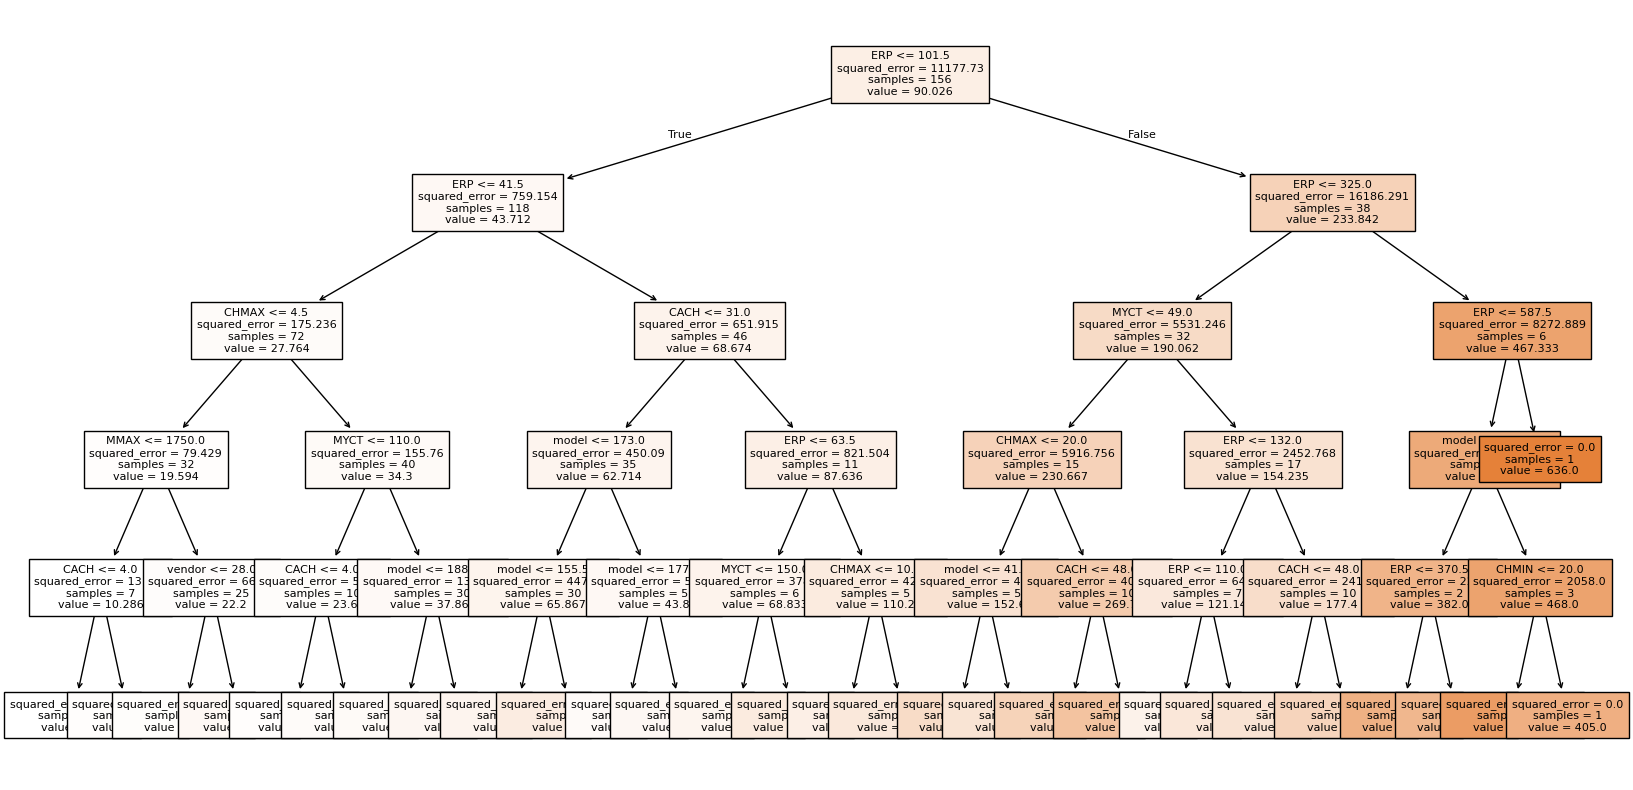

Step 6 done: Tree saved as decision_tree.png


In [50]:
# STEP 6: Plot and save the tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(model, feature_names=X.columns, filled=True, fontsize=8)
plt.savefig("decision_tree.png") # save ho jayega
plt.show()
print("Step 6 done: Tree saved as decision_tree.png")

In [51]:
import joblib

# model already train hai na
joblib.dump(model, 'prp_model.joblib')
print("Model saved as prp_model.joblib")

Model saved as prp_model.joblib
